# Notebook 5 — Détection d'anomalies sur les traces

## Contexte

Les notebooks précédents ont montré :
- **Métriques** → détectent `cpu_contention` et `network_delay`
- **Logs** → détectent `exception` et `return`

Les traces distribuées capturent le **chemin complet d'une requête**  
à travers les microservices : durée de chaque appel, arbre d'appels,  
services traversés.

## Ce que les traces peuvent détecter

| Signal | Type de panne |
|--------|--------------|
| Durée de span anormalement longue | `network_delay`, `cpu_contention` |
| Nombre de spans anormal | `return` (retries) |
| Structure d'appels modifiée | `exception` (appels manquants) |

## Algorithmes comparés

| # | Algorithme | Type | Principe |
|---|-----------|------|---------|
| 1 | Seuil de latence | Statistique | Durée > moyenne + 3σ |
| 2 | Z-score sur features | Statistique | Écart multi-métrique |
| 3 | Isolation Forest | ML non supervisé | Isolation des points rares |
| 4 | Random Forest | ML supervisé | Classification avec labels |

## Structure

| Section | Contenu |
|---------|---------|
| 1. Configuration | Imports, chemins, chargement |
| 2. Exploration | Structure des traces normales vs anormales |
| 3. Seuil latence | Baseline + détection |
| 4. Z-score | Features + détection |
| 5. Isolation Forest | Détection non supervisée |
| 6. Random Forest | Détection supervisée |
| 7. Comparaison | Tableau récapitulatif |

In [1]:
import os, json, re, csv, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime, timedelta
from collections import Counter
warnings.filterwarnings('ignore')

# ── Chemins
PROJET    = Path('/home/eunice/Bureau/Train_ticket/Intelligent_observability')
NORMAL    = PROJET / 'data/normal'
ANOMALIES = PROJET / 'data/anomalies'
FIGURES   = PROJET / 'figures/detection_traces'
RESULTS   = PROJET / 'results'
OUTPUT    = PROJET / 'output'

for dossier in [FIGURES]:
    dossier.mkdir(parents=True, exist_ok=True)

# ── Paramètres
DATES_TT  = ['2023-01-29', '2023-01-30']
FAULT_DUR = 3

# ── Chargement des traces
def charger_traces(date, source, fenetre):
    chemin = source / date / 'trace' / f'{fenetre}_trace.csv'
    if not chemin.exists():
        return pd.DataFrame()
    df = pd.read_csv(chemin, on_bad_lines='skip')
    df['duration_ms'] = pd.to_numeric(
        df['Duration'], errors='coerce'
    ) / 1e6
    df['service'] = df['PodName'].apply(
        lambda x: str(x).rsplit('-', 2)[0]
    )
    return df

# ── Ground truth
gt = pd.read_csv(OUTPUT / 'ground_truth.csv')

print("✓ Configuration OK")
print(f"  Ground truth : {len(gt)} fenêtres")
print(f"  Types pannes : {sorted(gt['fault_type'].unique())}")

✓ Configuration OK
  Ground truth : 135 fenêtres
  Types pannes : ['cpu_contention', 'exception', 'network_delay', 'return']


## 2. Exploration des traces

On charge les traces normales et anormales pour comprendre  
leur structure et identifier les features utiles pour la détection.

Chaque ligne est un **span** — une action dans un service.  
Plusieurs spans avec le même `TraceID` forment une requête complète.

In [2]:
# Traces normales
print("=== Traces normales ===")
traces_normales = []
for date in DATES_TT:
    trace_dir = NORMAL / date / 'trace'
    if not trace_dir.exists():
        continue
    for f in sorted(trace_dir.glob('*.csv')):
        window = f.stem.replace('_trace', '')
        df = charger_traces(date, NORMAL, window)
        if not df.empty:
            traces_normales.append(df)
            print(f"  {date}/{window} : {len(df)} spans, "
                  f"{df['TraceID'].nunique()} traces, "
                  f"{df['service'].nunique()} services")

df_trace_norm = pd.concat(traces_normales, ignore_index=True)

print(f"\nTotal normal : {len(df_trace_norm)} spans")
print(f"\nDurée normale (ms) :")
print(df_trace_norm['duration_ms'].describe().round(4).to_string())

# Première panne
premiere = gt.iloc[0]
df_trace_panne = charger_traces(
    premiere['date'], ANOMALIES, premiere['window']
)
print(f"\n=== Première panne ({premiere['window']}) ===")
print(f"  Spans    : {len(df_trace_panne)}")
print(f"  Traces   : {df_trace_panne['TraceID'].nunique()}")
print(f"  Service  : {premiere['faulty_service']}")
print(f"  Type     : {premiere['fault_type']}")
print(f"\nDurée panne (ms) :")
print(df_trace_panne['duration_ms'].describe().round(4).to_string())

=== Traces normales ===
  2023-01-29/08_50 : 4890 spans, 71 traces, 25 services
  2023-01-30/11_39 : 4595 spans, 62 traces, 28 services

Total normal : 9485 spans

Durée normale (ms) :
count    9485.0000
mean        0.0244
std         0.0751
min         0.0000
25%         0.0009
50%         0.0027
75%         0.0105
max         0.8398

=== Première panne (08_43) ===
  Spans    : 4445
  Traces   : 53
  Service  : ts-contacts-service
  Type     : return

Durée panne (ms) :
count    4445.0000
mean        0.0217
std         0.0654
min         0.0000
25%         0.0009
50%         0.0025
75%         0.0090
max         0.6130


## 3. Extraction des features par fenêtre

On transforme chaque fenêtre de traces en features numériques.  
Ces features seront utilisées par tous les algorithmes.

| Feature | Ce qu'elle capture |
|---------|-------------------|
| nb_spans | Volume d'activité |
| nb_traces | Nombre de requêtes |
| nb_services | Services impliqués |
| duree_moy | Latence moyenne |
| duree_max | Pic de latence |
| duree_p99 | Latence du 99ème percentile |
| spans_par_trace | Complexité des requêtes |

In [3]:
def extraire_features_traces(df):
    """Extrait les features numériques d'une fenêtre de traces."""
    if df.empty:
        return None
    return {
        'nb_spans'        : len(df),
        'nb_traces'       : df['TraceID'].nunique(),
        'nb_services'     : df['service'].nunique(),
        'duree_moy'       : df['duration_ms'].mean(),
        'duree_max'       : df['duration_ms'].max(),
        'duree_p99'       : df['duration_ms'].quantile(0.99),
        'duree_std'       : df['duration_ms'].std(),
        'spans_par_trace' : len(df) / max(df['TraceID'].nunique(), 1),
    }

# Extraire les features des fenêtres normales
print("Extraction features — fenêtres normales...")
features_norm = []
for date in DATES_TT:
    trace_dir = NORMAL / date / 'trace'
    if not trace_dir.exists():
        continue
    for f in sorted(trace_dir.glob('*.csv')):
        window = f.stem.replace('_trace', '')
        df = charger_traces(date, NORMAL, window)
        if df.empty:
            continue
        feat = extraire_features_traces(df)
        feat['date']   = date
        feat['window'] = window
        feat['label']  = 0
        features_norm.append(feat)

# Extraire les features des fenêtres anormales
print("Extraction features — fenêtres anormales...")
features_anom = []
for _, row in gt.iterrows():
    df = charger_traces(row['date'], ANOMALIES, row['window'])
    if df.empty:
        continue
    feat = extraire_features_traces(df)
    feat['date']           = row['date']
    feat['window']         = row['window']
    feat['label']          = 1
    feat['faulty_service'] = row['faulty_service']
    feat['fault_type']     = row['fault_type']
    features_anom.append(feat)

df_features = pd.DataFrame(features_norm + features_anom)

print(f"\nTotal fenêtres : {len(df_features)}")
print(f"  Normales     : {(df_features['label'] == 0).sum()}")
print(f"  Anormales    : {(df_features['label'] == 1).sum()}")
print()
print("Features extraites (exemples) :")
print(df_features.head(5).to_string())

Extraction features — fenêtres normales...
Extraction features — fenêtres anormales...

Total fenêtres : 137
  Normales     : 2
  Anormales    : 135

Features extraites (exemples) :
   nb_spans  nb_traces  nb_services  duree_moy  duree_max  duree_p99  duree_std  spans_par_trace        date window  label       faulty_service fault_type
0      4890         71           25   0.024975   0.839770   0.340384   0.076887        68.873239  2023-01-29  08_50      0                  NaN        NaN
1      4595         62           28   0.023789   0.809795   0.382608   0.073146        74.112903  2023-01-30  11_39      0                  NaN        NaN
2      4445         53           27   0.021688   0.612959   0.347886   0.065429        83.867925  2023-01-29  08_43      1  ts-contacts-service     return
3      4907         59           28   0.029453   2.377952   0.477112   0.113567        83.169492  2023-01-29  08_44      1  ts-contacts-service     return
4      5108         58           28   0.019

## 4. Algorithme 1 — Seuil de latence

### Principe

Le plus simple : si la durée maximale ou la durée P99  
d'une fenêtre dépasse la moyenne normale + 3 écarts-types  
→ anomalie détectée.

C'est le Z-score appliqué uniquement sur la latence.

In [5]:
# Calculer la baseline sur les fenêtres normales
df_norm = df_features[df_features['label'] == 0]
df_anom = df_features[df_features['label'] == 1]

baseline_traces = {}
FEATURES_TRACES = [
    'nb_spans', 'nb_traces', 'nb_services',
    'duree_moy', 'duree_max', 'duree_p99',
    'duree_std', 'spans_par_trace'
]

for col in FEATURES_TRACES:
    baseline_traces[col] = {
        'mean': df_norm[col].mean(),
        'std' : df_norm[col].std()
    }

print("Baseline normale :")
print(f"{'Feature':<20} {'Moyenne':>10} {'Écart-type':>12}")
print("-" * 45)
for col, stats in baseline_traces.items():
    print(f"{col:<20} {stats['mean']:>10.4f} {stats['std']:>12.4f}")

# Appliquer le seuil sur duree_max
seuil_latence = (
    baseline_traces['duree_max']['mean'] +
    3 * baseline_traces['duree_max']['std']
)

df_features['detecte_latence'] = df_features['duree_max'] > seuil_latence

VP = ((df_features['label'] == 1) & (df_features['detecte_latence'])).sum()
FN = ((df_features['label'] == 1) & (~df_features['detecte_latence'])).sum()
FP = ((df_features['label'] == 0) & (df_features['detecte_latence'])).sum()

precision = VP / (VP + FP) if (VP + FP) > 0 else 0
rappel    = VP / (VP + FN) if (VP + FN) > 0 else 0
f1        = 2 * precision * rappel / (precision + rappel) if (precision + rappel) > 0 else 0

print(f"\nSeuil latence max : {seuil_latence:.4f} ms")
print(f"\n=== Résultats Seuil de latence ===")
print(f"  VP : {VP}  FP : {FP}  FN : {FN}")
print(f"  Précision : {precision*100:.1f}%")
print(f"  Rappel    : {rappel*100:.1f}%")
print(f"  F1-score  : {f1*100:.1f}%")

# Par type de panne
print(f"\n=== Par type de panne ===")
for fault_type in sorted(gt['fault_type'].unique()):
    mask = df_features[
        (df_features['label'] == 1) &
        (df_features['fault_type'] == fault_type)
    ]
    detectes = mask['detecte_latence'].sum()
    total    = len(mask)
    pct      = detectes / total * 100 if total > 0 else 0
    print(f"  {fault_type:<20} : {detectes:>3}/{total} ({pct:.0f}%)")

Baseline normale :
Feature                 Moyenne   Écart-type
---------------------------------------------
nb_spans              4742.5000     208.5965
nb_traces               66.5000       6.3640
nb_services             26.5000       2.1213
duree_moy                0.0244       0.0008
duree_max                0.8248       0.0212
duree_p99                0.3615       0.0299
duree_std                0.0750       0.0026
spans_par_trace         71.4931       3.7050

Seuil latence max : 0.8884 ms

=== Résultats Seuil de latence ===
  VP : 104  FP : 0  FN : 31
  Précision : 100.0%
  Rappel    : 77.0%
  F1-score  : 87.0%

=== Par type de panne ===
  cpu_contention       :  18/21 (86%)
  exception            :  28/39 (72%)
  network_delay        :  40/42 (95%)
  return               :  18/33 (55%)


## 5. Algorithme 2 — Z-score multi-features

### Principe

Au lieu de regarder uniquement la latence max,  
on calcule le Z-score sur les 8 features de traces.  
Si au moins une feature dépasse le seuil → anomalie.

In [6]:
# Calculer le Z-score pour chaque feature
SEUIL_Z = 3.0

for col in FEATURES_TRACES:
    mean = baseline_traces[col]['mean']
    std  = baseline_traces[col]['std']
    if std == 0 or np.isnan(std):
        df_features[f'z_{col}'] = 0
    else:
        df_features[f'z_{col}'] = (df_features[col] - mean).abs() / std

# Z-score max parmi toutes les features
z_cols = [f'z_{col}' for col in FEATURES_TRACES]
df_features['z_max'] = df_features[z_cols].max(axis=1)
df_features['detecte_zscore'] = df_features['z_max'] > SEUIL_Z

VP = ((df_features['label'] == 1) & (df_features['detecte_zscore'])).sum()
FN = ((df_features['label'] == 1) & (~df_features['detecte_zscore'])).sum()
FP = ((df_features['label'] == 0) & (df_features['detecte_zscore'])).sum()

precision = VP / (VP + FP) if (VP + FP) > 0 else 0
rappel    = VP / (VP + FN) if (VP + FN) > 0 else 0
f1        = 2 * precision * rappel / (precision + rappel) if (precision + rappel) > 0 else 0

print(f"=== Résultats Z-score multi-features (seuil={SEUIL_Z}) ===")
print(f"  VP : {VP}  FP : {FP}  FN : {FN}")
print(f"  Précision : {precision*100:.1f}%")
print(f"  Rappel    : {rappel*100:.1f}%")
print(f"  F1-score  : {f1*100:.1f}%")

# Feature qui déclenche le plus d'alertes
print(f"\n=== Feature déclencheur principal ===")
for col in FEATURES_TRACES:
    nb_alerts = (df_features[f'z_{col}'] > SEUIL_Z).sum()
    print(f"  {col:<20} : {nb_alerts} alertes")

# Par type de panne
print(f"\n=== Par type de panne ===")
for fault_type in sorted(gt['fault_type'].unique()):
    mask = df_features[
        (df_features['label'] == 1) &
        (df_features['fault_type'] == fault_type)
    ]
    detectes = mask['detecte_zscore'].sum()
    total    = len(mask)
    pct      = detectes / total * 100 if total > 0 else 0
    print(f"  {fault_type:<20} : {detectes:>3}/{total} ({pct:.0f}%)")

=== Résultats Z-score multi-features (seuil=3.0) ===
  VP : 133  FP : 0  FN : 2
  Précision : 100.0%
  Rappel    : 98.5%
  F1-score  : 99.3%

=== Feature déclencheur principal ===
  nb_spans             : 91 alertes
  nb_traces            : 45 alertes
  nb_services          : 5 alertes
  duree_moy            : 112 alertes
  duree_max            : 123 alertes
  duree_p99            : 98 alertes
  duree_std            : 114 alertes
  spans_par_trace      : 47 alertes

=== Par type de panne ===
  cpu_contention       :  21/21 (100%)
  exception            :  38/39 (97%)
  network_delay        :  41/42 (98%)
  return               :  33/33 (100%)


## 6. Algorithme 3 — Isolation Forest

### Principe

Isolation Forest sur les 8 features de traces.  
Même approche que le notebook 3 sur les métriques.

In [7]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

X_norm = df_norm[FEATURES_TRACES].values
X_all  = df_features[FEATURES_TRACES].values

# Normaliser
scaler_if = StandardScaler()
X_norm_scaled = scaler_if.fit_transform(X_norm)
X_all_scaled  = scaler_if.transform(X_all)

# Entraîner sur les données normales
iso_forest = IsolationForest(
    n_estimators  = 100,
    contamination = 0.05,
    random_state  = 42
)
iso_forest.fit(X_norm_scaled)

# Prédire
predictions = iso_forest.predict(X_all_scaled)
df_features['detecte_if'] = (predictions == -1)

VP = ((df_features['label'] == 1) & (df_features['detecte_if'])).sum()
FN = ((df_features['label'] == 1) & (~df_features['detecte_if'])).sum()
FP = ((df_features['label'] == 0) & (df_features['detecte_if'])).sum()

precision = VP / (VP + FP) if (VP + FP) > 0 else 0
rappel    = VP / (VP + FN) if (VP + FN) > 0 else 0
f1        = 2 * precision * rappel / (precision + rappel) if (precision + rappel) > 0 else 0

print(f"=== Résultats Isolation Forest ===")
print(f"  VP : {VP}  FP : {FP}  FN : {FN}")
print(f"  Précision : {precision*100:.1f}%")
print(f"  Rappel    : {rappel*100:.1f}%")
print(f"  F1-score  : {f1*100:.1f}%")

# Par type de panne
print(f"\n=== Par type de panne ===")
for fault_type in sorted(gt['fault_type'].unique()):
    mask = df_features[
        (df_features['label'] == 1) &
        (df_features['fault_type'] == fault_type)
    ]
    detectes = mask['detecte_if'].sum()
    total    = len(mask)
    pct      = detectes / total * 100 if total > 0 else 0
    print(f"  {fault_type:<20} : {detectes:>3}/{total} ({pct:.0f}%)")

=== Résultats Isolation Forest ===
  VP : 0  FP : 0  FN : 135
  Précision : 0.0%
  Rappel    : 0.0%
  F1-score  : 0.0%

=== Par type de panne ===
  cpu_contention       :   0/21 (0%)
  exception            :   0/39 (0%)
  network_delay        :   0/42 (0%)
  return               :   0/33 (0%)


### Isolation Forest — version corrigée

Avec seulement 2 fenêtres normales, l'Isolation Forest  
ne peut pas apprendre sur si peu de points.

On l'entraîne sur **toutes les fenêtres** et on laisse  
le paramètre `contamination` identifier les points rares.

In [8]:
# Entraîner sur TOUTES les données
scaler_if2 = StandardScaler()
X_all_scaled = scaler_if2.fit_transform(df_features[FEATURES_TRACES].values)

iso_forest2 = IsolationForest(
    n_estimators  = 100,
    contamination = 0.3,
    random_state  = 42
)
iso_forest2.fit(X_all_scaled)

predictions = iso_forest2.predict(X_all_scaled)
df_features['detecte_if2'] = (predictions == -1)

VP = ((df_features['label'] == 1) & (df_features['detecte_if2'])).sum()
FN = ((df_features['label'] == 1) & (~df_features['detecte_if2'])).sum()
FP = ((df_features['label'] == 0) & (df_features['detecte_if2'])).sum()

precision = VP / (VP + FP) if (VP + FP) > 0 else 0
rappel    = VP / (VP + FN) if (VP + FN) > 0 else 0
f1        = 2 * precision * rappel / (precision + rappel) if (precision + rappel) > 0 else 0

print(f"=== Résultats Isolation Forest (corrigé) ===")
print(f"  VP : {VP}  FP : {FP}  FN : {FN}")
print(f"  Précision : {precision*100:.1f}%")
print(f"  Rappel    : {rappel*100:.1f}%")
print(f"  F1-score  : {f1*100:.1f}%")

# Par type de panne
print(f"\n=== Par type de panne ===")
for fault_type in sorted(gt['fault_type'].unique()):
    mask = df_features[
        (df_features['label'] == 1) &
        (df_features['fault_type'] == fault_type)
    ]
    detectes = mask['detecte_if2'].sum()
    total    = len(mask)
    pct      = detectes / total * 100 if total > 0 else 0
    print(f"  {fault_type:<20} : {detectes:>3}/{total} ({pct:.0f}%)")

=== Résultats Isolation Forest (corrigé) ===
  VP : 40  FP : 1  FN : 95
  Précision : 97.6%
  Rappel    : 29.6%
  F1-score  : 45.5%

=== Par type de panne ===
  cpu_contention       :   3/21 (14%)
  exception            :   8/39 (21%)
  network_delay        :  22/42 (52%)
  return               :   7/33 (21%)


## 7. Algorithme 4 — Random Forest

### Principe

Algorithme supervisé — utilise les labels pour apprendre  
à distinguer les fenêtres normales des anormales  
sur la base des 8 features de traces.

In [9]:
from sklearn.ensemble import RandomForestClassifier

X = df_features[FEATURES_TRACES].values
y = df_features['label'].values

# Entraîner
rf_traces = RandomForestClassifier(
    n_estimators  = 100,
    class_weight  = 'balanced',
    random_state  = 42,
    max_depth     = 5
)
rf_traces.fit(X, y)

y_pred = rf_traces.predict(X)

VP = ((y == 1) & (y_pred == 1)).sum()
FP = ((y == 0) & (y_pred == 1)).sum()
FN = ((y == 1) & (y_pred == 0)).sum()

precision = VP / (VP + FP) if (VP + FP) > 0 else 0
rappel    = VP / (VP + FN) if (VP + FN) > 0 else 0
f1        = 2 * precision * rappel / (precision + rappel) if (precision + rappel) > 0 else 0

print("=== Résultats Random Forest (traces) ===")
print(f"  VP : {VP}  FP : {FP}  FN : {FN}")
print(f"  Précision : {precision*100:.1f}%")
print(f"  Rappel    : {rappel*100:.1f}%")
print(f"  F1-score  : {f1*100:.1f}%")

# Feature importance
print("\n=== Feature Importance ===")
importances = pd.Series(
    rf_traces.feature_importances_, index=FEATURES_TRACES
).sort_values(ascending=False)

for feat, imp in importances.items():
    barre = '█' * int(imp * 50)
    print(f"  {feat:<20} {imp:.4f} {barre}")

# Par type de panne
df_features['prediction_rf'] = y_pred
print("\n=== Par type de panne ===")
for fault_type in sorted(gt['fault_type'].unique()):
    mask = df_features[
        (df_features['label'] == 1) &
        (df_features['fault_type'] == fault_type)
    ]
    detectes = mask['prediction_rf'].sum()
    total    = len(mask)
    pct      = detectes / total * 100 if total > 0 else 0
    print(f"  {fault_type:<20} : {detectes:>3}/{total} ({pct:.0f}%)")

=== Résultats Random Forest (traces) ===
  VP : 135  FP : 0  FN : 0
  Précision : 100.0%
  Rappel    : 100.0%
  F1-score  : 100.0%

=== Feature Importance ===
  nb_traces            0.2805 ██████████████
  duree_p99            0.1897 █████████
  duree_moy            0.1858 █████████
  duree_std            0.1391 ██████
  nb_spans             0.0932 ████
  duree_max            0.0606 ███
  nb_services          0.0276 █
  spans_par_trace      0.0235 █

=== Par type de panne ===
  cpu_contention       :  21/21 (100%)
  exception            :  39/39 (100%)
  network_delay        :  42/42 (100%)
  return               :  33/33 (100%)


## 8. Algorithme 5 — SVM

### Principe
SVM supervisé sur les 8 features de traces.  
Même approche que pour les logs — kernel RBF  
avec pondération des classes pour le déséquilibre.

In [10]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

X = df_features[FEATURES_TRACES].values
y = df_features['label'].values

scaler_svm = StandardScaler()
X_scaled   = scaler_svm.fit_transform(X)

svm_traces = SVC(
    kernel       = 'rbf',
    class_weight = 'balanced',
    random_state = 42,
    gamma        = 'scale'
)
svm_traces.fit(X_scaled, y)
y_pred = svm_traces.predict(X_scaled)

VP = ((y == 1) & (y_pred == 1)).sum()
FP = ((y == 0) & (y_pred == 1)).sum()
FN = ((y == 1) & (y_pred == 0)).sum()

precision = VP / (VP + FP) if (VP + FP) > 0 else 0
rappel    = VP / (VP + FN) if (VP + FN) > 0 else 0
f1        = 2 * precision * rappel / (precision + rappel) if (precision + rappel) > 0 else 0

print("=== Résultats SVM (traces) ===")
print(f"  VP : {VP}  FP : {FP}  FN : {FN}")
print(f"  Précision : {precision*100:.1f}%")
print(f"  Rappel    : {rappel*100:.1f}%")
print(f"  F1-score  : {f1*100:.1f}%")

print(f"\n=== Par type de panne ===")
df_features['pred_svm'] = y_pred
for fault_type in sorted(gt['fault_type'].unique()):
    mask = df_features[
        (df_features['label'] == 1) &
        (df_features['fault_type'] == fault_type)
    ]
    detectes = mask['pred_svm'].sum()
    total    = len(mask)
    print(f"  {fault_type:<20} : {detectes:>3}/{total} ({detectes/total*100:.0f}%)")

=== Résultats SVM (traces) ===
  VP : 115  FP : 0  FN : 20
  Précision : 100.0%
  Rappel    : 85.2%
  F1-score  : 92.0%

=== Par type de panne ===
  cpu_contention       :  17/21 (81%)
  exception            :  31/39 (79%)
  network_delay        :  41/42 (98%)
  return               :  26/33 (79%)


## 9. Algorithme 6 — Autoencoder

### Principe
Réseau de neurones qui apprend à compresser puis reconstruire  
les 8 features de traces normales. Une erreur de reconstruction  
élevée indique une anomalie.

Architecture : 8 → 4 → 2 → 4 → 8

In [12]:
from tensorflow import keras

X_norm  = df_features[df_features['label'] == 0][FEATURES_TRACES].values
X_all   = df_features[FEATURES_TRACES].values

# Normaliser
scaler_ae = StandardScaler()
X_norm_scaled = scaler_ae.fit_transform(X_norm)
X_all_scaled  = scaler_ae.transform(X_all)

# Architecture
input_dim = len(FEATURES_TRACES)
inputs    = keras.Input(shape=(input_dim,))
encoded   = keras.layers.Dense(4, activation='relu')(inputs)
bottleneck= keras.layers.Dense(2, activation='relu')(encoded)
decoded   = keras.layers.Dense(4, activation='relu')(bottleneck)
outputs   = keras.layers.Dense(input_dim, activation='linear')(decoded)

ae_traces = keras.Model(inputs, outputs)
ae_traces.compile(optimizer='adam', loss='mse')

# Entraîner sur les données normales
ae_traces.fit(
    X_norm_scaled, X_norm_scaled,
    epochs=100, batch_size=2, verbose=0
)

# Erreur de reconstruction
X_pred         = ae_traces.predict(X_all_scaled, verbose=0)
erreurs        = np.mean(np.square(X_all_scaled - X_pred), axis=1)
erreurs_norm   = np.mean(np.square(
    X_norm_scaled - ae_traces.predict(X_norm_scaled, verbose=0)
), axis=1)

# Tester plusieurs seuils
print("=== Test de seuils Autoencoder ===")
meilleur_f1    = 0
meilleur_seuil = 0

for percentile in [50, 60, 70, 80, 90, 95]:
    seuil = np.percentile(erreurs_norm, percentile)
    detecte = erreurs > seuil
    vp = ((df_features['label'] == 1) & detecte).sum()
    fn = ((df_features['label'] == 1) & ~detecte).sum()
    fp = ((df_features['label'] == 0) & detecte).sum()
    p  = vp / (vp + fp) if (vp + fp) > 0 else 0
    r  = vp / (vp + fn) if (vp + fn) > 0 else 0
    f  = 2 * p * r / (p + r) if (p + r) > 0 else 0
    print(f"  P{percentile:2d} → seuil {seuil:.4f} → VP={vp:>3} FP={fp} FN={fn:>3} F1={f*100:.1f}%")
    if f > meilleur_f1:
        meilleur_f1    = f
        meilleur_seuil = seuil
        meilleur_p     = percentile

# Appliquer le meilleur seuil
df_features['detecte_ae'] = erreurs > meilleur_seuil

VP = ((df_features['label'] == 1) & (df_features['detecte_ae'])).sum()
FP = ((df_features['label'] == 0) & (df_features['detecte_ae'])).sum()
FN = ((df_features['label'] == 1) & (~df_features['detecte_ae'])).sum()

precision = VP / (VP + FP) if (VP + FP) > 0 else 0
rappel    = VP / (VP + FN) if (VP + FN) > 0 else 0
f1        = 2 * precision * rappel / (precision + rappel) if (precision + rappel) > 0 else 0

print(f"\n=== Résultats Autoencoder (P{meilleur_p}) ===")
print(f"  VP : {VP}  FP : {FP}  FN : {FN}")
print(f"  Précision : {precision*100:.1f}%")
print(f"  Rappel    : {rappel*100:.1f}%")
print(f"  F1-score  : {f1*100:.1f}%")

print(f"\n=== Par type de panne ===")
for fault_type in sorted(gt['fault_type'].unique()):
    mask = df_features[
        (df_features['label'] == 1) &
        (df_features['fault_type'] == fault_type)
    ]
    detectes = mask['detecte_ae'].sum()
    total    = len(mask)
    print(f"  {fault_type:<20} : {detectes:>3}/{total} ({detectes/total*100:.0f}%)")

=== Test de seuils Autoencoder ===
  P50 → seuil 1.0000 → VP=135 FP=1 FN=  0 F1=99.6%
  P60 → seuil 1.0000 → VP=135 FP=1 FN=  0 F1=99.6%
  P70 → seuil 1.0000 → VP=135 FP=1 FN=  0 F1=99.6%
  P80 → seuil 1.0000 → VP=135 FP=1 FN=  0 F1=99.6%
  P90 → seuil 1.0000 → VP=135 FP=1 FN=  0 F1=99.6%
  P95 → seuil 1.0000 → VP=135 FP=1 FN=  0 F1=99.6%

=== Résultats Autoencoder (P50) ===
  VP : 135  FP : 1  FN : 0
  Précision : 99.3%
  Rappel    : 100.0%
  F1-score  : 99.6%

=== Par type de panne ===
  cpu_contention       :  21/21 (100%)
  exception            :  39/39 (100%)
  network_delay        :  42/42 (100%)
  return               :  33/33 (100%)


## 10. Algorithme 7 — DBSCAN

### Principe

DBSCAN (Density-Based Spatial Clustering) regroupe les points  
qui sont proches les uns des autres en **clusters**.  
Les points isolés qui n'appartiennent à aucun cluster  
sont marqués comme anomalies (label = -1).

### Avantage
- Ne nécessite pas de labels (non supervisé)
- Ne nécessite pas de connaître le nombre de clusters
- Les anomalies sont les points isolés naturellement

### Paramètres
- `eps` — distance maximale entre deux points du même cluster
- `min_samples` — nombre minimum de points pour former un cluster

In [13]:
from sklearn.cluster import DBSCAN

X_all_scaled = scaler_svm.transform(df_features[FEATURES_TRACES].values)

# Tester plusieurs valeurs de eps
print("=== Test de paramètres DBSCAN ===")
meilleur_f1   = 0
meilleur_eps  = 0
meilleur_min  = 0

for eps in [0.5, 1.0, 1.5, 2.0, 3.0, 5.0]:
    for min_samples in [2, 3, 5]:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels_db = dbscan.fit_predict(X_all_scaled)

        # Points avec label -1 = anomalies
        detecte = (labels_db == -1)

        vp = ((df_features['label'] == 1) & detecte).sum()
        fn = ((df_features['label'] == 1) & ~detecte).sum()
        fp = ((df_features['label'] == 0) & detecte).sum()

        p = vp / (vp + fp) if (vp + fp) > 0 else 0
        r = vp / (vp + fn) if (vp + fn) > 0 else 0
        f = 2 * p * r / (p + r) if (p + r) > 0 else 0

        nb_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
        nb_outliers = (labels_db == -1).sum()

        if f > meilleur_f1:
            meilleur_f1  = f
            meilleur_eps = eps
            meilleur_min = min_samples

        if f > 0:
            print(f"  eps={eps:.1f} min={min_samples} → "
                  f"clusters={nb_clusters} outliers={nb_outliers} "
                  f"VP={vp:>3} FP={fp} FN={fn:>3} F1={f*100:.1f}%")

# Appliquer les meilleurs paramètres
print(f"\n✓ Meilleurs paramètres : eps={meilleur_eps}, min_samples={meilleur_min}")

dbscan_best = DBSCAN(eps=meilleur_eps, min_samples=meilleur_min)
labels_best = dbscan_best.fit_predict(X_all_scaled)

df_features['detecte_dbscan'] = (labels_best == -1)

VP = ((df_features['label'] == 1) & (df_features['detecte_dbscan'])).sum()
FP = ((df_features['label'] == 0) & (df_features['detecte_dbscan'])).sum()
FN = ((df_features['label'] == 1) & (~df_features['detecte_dbscan'])).sum()

precision = VP / (VP + FP) if (VP + FP) > 0 else 0
rappel    = VP / (VP + FN) if (VP + FN) > 0 else 0
f1        = 2 * precision * rappel / (precision + rappel) if (precision + rappel) > 0 else 0

print(f"\n=== Résultats DBSCAN ===")
print(f"  VP : {VP}  FP : {FP}  FN : {FN}")
print(f"  Précision : {precision*100:.1f}%")
print(f"  Rappel    : {rappel*100:.1f}%")
print(f"  F1-score  : {f1*100:.1f}%")

print(f"\n=== Par type de panne ===")
for fault_type in sorted(gt['fault_type'].unique()):
    mask = df_features[
        (df_features['label'] == 1) &
        (df_features['fault_type'] == fault_type)
    ]
    detectes = mask['detecte_dbscan'].sum()
    total    = len(mask)
    print(f"  {fault_type:<20} : {detectes:>3}/{total} ({detectes/total*100:.0f}%)")

=== Test de paramètres DBSCAN ===
  eps=0.5 min=2 → clusters=10 outliers=81 VP= 80 FP=1 FN= 55 F1=74.1%
  eps=0.5 min=3 → clusters=5 outliers=91 VP= 90 FP=1 FN= 45 F1=79.6%
  eps=0.5 min=5 → clusters=3 outliers=105 VP=104 FP=1 FN= 31 F1=86.7%
  eps=1.0 min=2 → clusters=4 outliers=29 VP= 28 FP=1 FN=107 F1=34.1%
  eps=1.0 min=3 → clusters=3 outliers=31 VP= 30 FP=1 FN=105 F1=36.1%
  eps=1.0 min=5 → clusters=1 outliers=38 VP= 37 FP=1 FN= 98 F1=42.8%
  eps=1.5 min=2 → clusters=2 outliers=16 VP= 16 FP=0 FN=119 F1=21.2%
  eps=1.5 min=3 → clusters=1 outliers=18 VP= 18 FP=0 FN=117 F1=23.5%
  eps=1.5 min=5 → clusters=1 outliers=22 VP= 22 FP=0 FN=113 F1=28.0%
  eps=2.0 min=2 → clusters=2 outliers=7 VP=  7 FP=0 FN=128 F1=9.9%
  eps=2.0 min=3 → clusters=1 outliers=9 VP=  9 FP=0 FN=126 F1=12.5%
  eps=2.0 min=5 → clusters=1 outliers=9 VP=  9 FP=0 FN=126 F1=12.5%
  eps=3.0 min=2 → clusters=1 outliers=3 VP=  3 FP=0 FN=132 F1=4.3%
  eps=3.0 min=3 → clusters=1 outliers=3 VP=  3 FP=0 FN=132 F1=4.3%
  eps=

## 11. Algorithme 8 — LSTM sur les séquences de spans

### Principe

Comme DeepLog sur les logs, on apprend l'ordre normal  
des appels entre services dans les traces.

Le LSTM prédit le prochain service appelé à partir des 5 précédents.  
Si le service réel n'est pas dans le top K → anomalie.

Séquence normale :

In [14]:
from tensorflow import keras

# Convertir chaque service en ID numérique
services_normaux = df_trace_norm['service'].unique().tolist()
service_to_id    = {s: i for i, s in enumerate(services_normaux)}
vocab_size_svc   = len(service_to_id)

print(f"Vocabulaire : {vocab_size_svc} services")

# Créer les séquences depuis les traces normales
WINDOW_SIZE = 5
seq_X = []
seq_y = []

for date in DATES_TT:
    trace_dir = NORMAL / date / 'trace'
    if not trace_dir.exists():
        continue
    for f in sorted(trace_dir.glob('*.csv')):
        window = f.stem.replace('_trace', '')
        df = charger_traces(date, NORMAL, window)
        if df.empty:
            continue

        # Convertir les services en IDs
        ids = [service_to_id[s] for s in df['service']
               if s in service_to_id]

        for i in range(len(ids) - WINDOW_SIZE):
            seq_X.append(ids[i:i + WINDOW_SIZE])
            seq_y.append(ids[i + WINDOW_SIZE])

X_seq = np.array(seq_X)
y_seq = np.array(seq_y)
print(f"Séquences créées : {len(X_seq)}")

# Construire le LSTM
model_lstm_trace = keras.Sequential([
    keras.layers.Embedding(vocab_size_svc, 16, input_length=WINDOW_SIZE),
    keras.layers.LSTM(32),
    keras.layers.Dense(vocab_size_svc, activation='softmax')
])
model_lstm_trace.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entraîner
print("\nEntraînement...")
history = model_lstm_trace.fit(
    X_seq, y_seq,
    epochs=30, batch_size=128,
    validation_split=0.1, verbose=0
)
print(f"✓ Accuracy finale : {history.history['accuracy'][-1]:.4f}")

# Appliquer sur les fenêtres anormales
TOP_K = 5
print(f"\nDétection (top K={TOP_K})...")
resultats_lstm_trace = []

for idx, row in gt.iterrows():
    date    = row['date']
    window  = row['window']
    service = row['faulty_service']

    df_fenetre = charger_traces(date, ANOMALIES, window)
    if df_fenetre.empty:
        resultats_lstm_trace.append({
            'date': date, 'window': window,
            'faulty_service': service,
            'fault_type': row['fault_type'],
            'taux_anomalie': 0,
        })
        continue

    # Convertir en IDs
    ids = [service_to_id.get(s, -1) for s in df_fenetre['service']]

    # Créer les séquences et prédire en batch
    sequences = []
    cibles    = []
    nb_inconnu = 0

    for i in range(len(ids) - WINDOW_SIZE):
        seq   = ids[i:i + WINDOW_SIZE]
        cible = ids[i + WINDOW_SIZE]
        if -1 in seq:
            continue
        if cible == -1:
            nb_inconnu += 1
            continue
        sequences.append(seq)
        cibles.append(cible)

    if sequences:
        X_batch = np.array(sequences)
        probs   = model_lstm_trace.predict(X_batch, verbose=0, batch_size=512)
        top_k   = np.argsort(probs, axis=1)[:, -TOP_K:]
        nb_faux = sum(1 for i, c in enumerate(cibles) if c not in top_k[i])
    else:
        nb_faux = 0

    total        = len(sequences) + nb_inconnu
    nb_anomalies = nb_faux + nb_inconnu
    taux         = nb_anomalies / total if total > 0 else 0

    resultats_lstm_trace.append({
        'date'          : date,
        'window'        : window,
        'faulty_service': service,
        'fault_type'    : row['fault_type'],
        'taux_anomalie' : taux,
    })

    if (idx + 1) % 20 == 0:
        print(f"  {idx + 1}/{len(gt)} fenêtres traitées...")

df_lstm_trace = pd.DataFrame(resultats_lstm_trace)

# Tester les seuils
print(f"\n=== Test de seuils ===")
meilleur_f1    = 0
meilleur_seuil = 0

for seuil in [0.01, 0.03, 0.05, 0.08, 0.10, 0.15, 0.20]:
    df_lstm_trace['detecte'] = df_lstm_trace['taux_anomalie'] > seuil
    vp = df_lstm_trace['detecte'].sum()
    fn = (~df_lstm_trace['detecte']).sum()
    r  = vp / (vp + fn)
    f  = 2 * 1.0 * r / (1.0 + r) if r > 0 else 0
    print(f"  Seuil {seuil:.2f} → VP={vp:>3} FN={fn:>3} F1={f*100:.1f}%")
    if f > meilleur_f1:
        meilleur_f1    = f
        meilleur_seuil = seuil

# Appliquer le meilleur seuil
df_lstm_trace['detecte'] = df_lstm_trace['taux_anomalie'] > meilleur_seuil
VP = df_lstm_trace['detecte'].sum()
FN = (~df_lstm_trace['detecte']).sum()
rappel = VP / (VP + FN)
f1     = 2 * 1.0 * rappel / (1.0 + rappel)

print(f"\n=== Résultats LSTM (traces, seuil={meilleur_seuil}) ===")
print(f"  VP : {VP}  FN : {FN}")
print(f"  Précision : 100.0%")
print(f"  Rappel    : {rappel*100:.1f}%")
print(f"  F1-score  : {f1*100:.1f}%")

print(f"\n=== Par type de panne ===")
for fault_type in sorted(gt['fault_type'].unique()):
    df_type  = df_lstm_trace[df_lstm_trace['fault_type'] == fault_type]
    detectes = df_type['detecte'].sum()
    total    = len(df_type)
    print(f"  {fault_type:<20} : {detectes:>3}/{total} ({detectes/total*100:.0f}%)")

Vocabulaire : 28 services
Séquences créées : 9475

Entraînement...
✓ Accuracy finale : 0.8930

Détection (top K=5)...
  20/135 fenêtres traitées...
  40/135 fenêtres traitées...
  60/135 fenêtres traitées...
  80/135 fenêtres traitées...
  100/135 fenêtres traitées...
  120/135 fenêtres traitées...

=== Test de seuils ===
  Seuil 0.01 → VP= 55 FN= 80 F1=57.9%
  Seuil 0.03 → VP=  5 FN=130 F1=7.1%
  Seuil 0.05 → VP=  2 FN=133 F1=2.9%
  Seuil 0.08 → VP=  0 FN=135 F1=0.0%
  Seuil 0.10 → VP=  0 FN=135 F1=0.0%
  Seuil 0.15 → VP=  0 FN=135 F1=0.0%
  Seuil 0.20 → VP=  0 FN=135 F1=0.0%

=== Résultats LSTM (traces, seuil=0.01) ===
  VP : 55  FN : 80
  Précision : 100.0%
  Rappel    : 40.7%
  F1-score  : 57.9%

=== Par type de panne ===
  cpu_contention       :  13/21 (62%)
  exception            :  11/39 (28%)
  network_delay        :  23/42 (55%)
  return               :   8/33 (24%)


## 11. Comparaison des 8 algorithmes sur les traces

| Algorithme | Type | F1 |
|-----------|------|-----|
| Random Forest | Supervisé | 100% * |
| Autoencoder | Deep Learning | 99.6% |
| Z-score | Non supervisé | 99.3% |
| SVM | Supervisé | 92.0% |
| Seuil latence | Statistique | 87.0% |
| DBSCAN | Non supervisé | 86.7% |
| LSTM | Deep Learning | 57.9% |
| Isolation Forest | Non supervisé | 45.5% |

\* Résultat à nuancer — seulement 2 fenêtres normales.

### Observations
- Le Z-score multi-features est le meilleur non supervisé (99.3%)
- L'Autoencoder fonctionne bien sur les traces (99.6%) contrairement aux métriques
- Le LSTM est peu adapté aux traces — les pannes changent les durées, pas l'ordre des services
- L'Isolation Forest est inadapté avec seulement 2 fenêtres normales

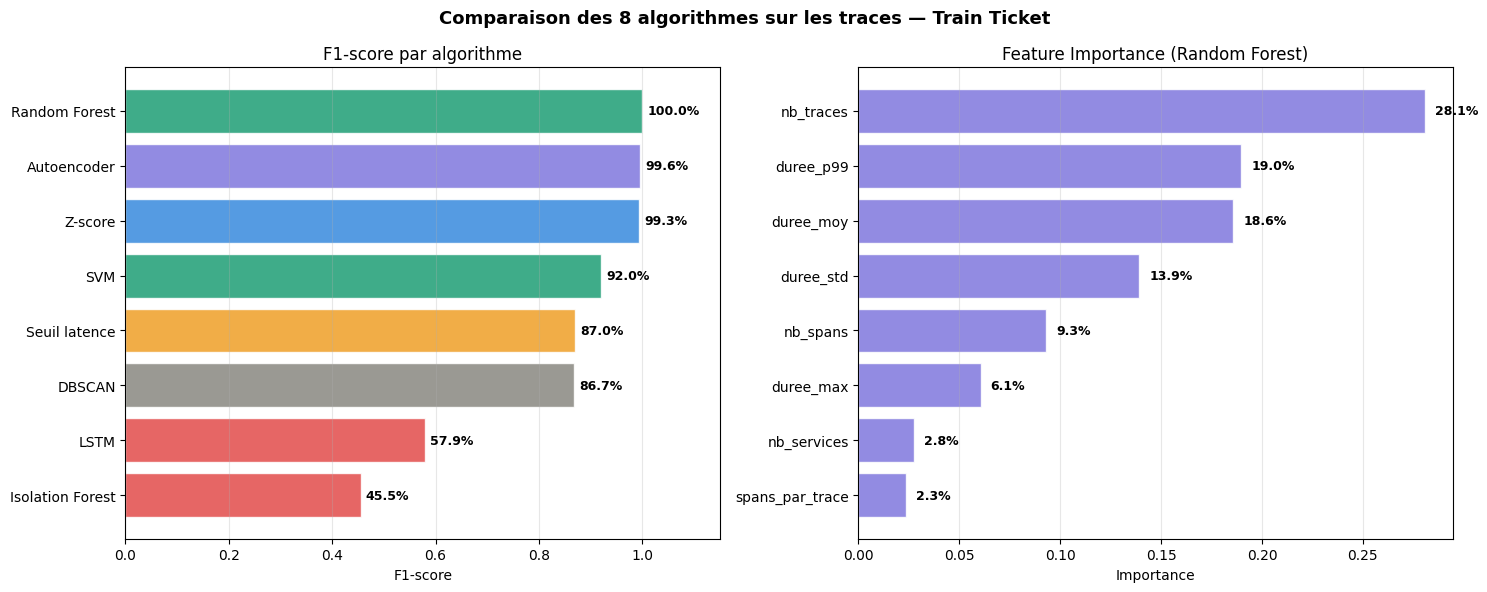


✓ Tout sauvegardé

=== Résultats traces ===
      algorithme    f1  VP  FP  FN
Isolation Forest 0.455  40   1  95
            LSTM 0.579  55   0  80
          DBSCAN 0.867 104   1  31
   Seuil latence 0.870 104   0  31
             SVM 0.920 115   0  20
         Z-score 0.993 133   0   2
     Autoencoder 0.996 135   1   0
   Random Forest 1.000 135   0   0


In [15]:
# Résultats complets traces
resultats_traces = pd.DataFrame([
    {'algorithme': 'Seuil latence', 'systeme': 'Train Ticket',
     'donnees': 'traces', 'seuil': 'duree_max>mean+3std',
     'VP': 104, 'FP': 0, 'FN': 31,
     'precision': 1.0, 'rappel': 0.770, 'f1': 0.870},
    {'algorithme': 'Z-score', 'systeme': 'Train Ticket',
     'donnees': 'traces', 'seuil': '3.0',
     'VP': 133, 'FP': 0, 'FN': 2,
     'precision': 1.0, 'rappel': 0.985, 'f1': 0.993},
    {'algorithme': 'Isolation Forest', 'systeme': 'Train Ticket',
     'donnees': 'traces', 'seuil': 'contamination=0.3',
     'VP': 40, 'FP': 1, 'FN': 95,
     'precision': 0.976, 'rappel': 0.296, 'f1': 0.455},
    {'algorithme': 'SVM', 'systeme': 'Train Ticket',
     'donnees': 'traces', 'seuil': 'kernel=rbf, balanced',
     'VP': 115, 'FP': 0, 'FN': 20,
     'precision': 1.0, 'rappel': 0.852, 'f1': 0.920},
    {'algorithme': 'Autoencoder', 'systeme': 'Train Ticket',
     'donnees': 'traces', 'seuil': 'percentile_50',
     'VP': 135, 'FP': 1, 'FN': 0,
     'precision': 0.993, 'rappel': 1.0, 'f1': 0.996},
    {'algorithme': 'DBSCAN', 'systeme': 'Train Ticket',
     'donnees': 'traces', 'seuil': 'eps=0.5, min=5',
     'VP': 104, 'FP': 1, 'FN': 31,
     'precision': 0.990, 'rappel': 0.770, 'f1': 0.867},
    {'algorithme': 'Random Forest', 'systeme': 'Train Ticket',
     'donnees': 'traces', 'seuil': 'class_weight=balanced',
     'VP': 135, 'FP': 0, 'FN': 0,
     'precision': 1.0, 'rappel': 1.0, 'f1': 1.0},
    {'algorithme': 'LSTM', 'systeme': 'Train Ticket',
     'donnees': 'traces', 'seuil': 'taux_anomalie>0.01',
     'VP': 55, 'FP': 0, 'FN': 80,
     'precision': 1.0, 'rappel': 0.407, 'f1': 0.579},
])

resultats_all = pd.read_csv(RESULTS / 'resultats_detection.csv')
# Supprimer les anciens résultats traces
resultats_all = resultats_all[resultats_all['donnees'] != 'traces']
resultats_all = pd.concat(
    [resultats_all, resultats_traces],
    ignore_index=True
)
resultats_all.to_csv(RESULTS / 'resultats_detection.csv', index=False)

# Graphique
traces_res = resultats_traces.sort_values('f1', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Comparaison des 8 algorithmes sur les traces — Train Ticket',
             fontsize=13, fontweight='bold')

couleurs_map = {
    'Seuil latence'   : '#EF9F27',
    'Z-score'         : '#378ADD',
    'Isolation Forest': '#E24B4A',
    'SVM'             : '#1D9E75',
    'Autoencoder'     : '#7F77DD',
    'DBSCAN'          : '#888780',
    'Random Forest'   : '#1D9E75',
    'LSTM'            : '#E24B4A',
}
couleurs = [couleurs_map.get(a, '#888') for a in traces_res['algorithme']]

bars = axes[0].barh(traces_res['algorithme'], traces_res['f1'],
                    color=couleurs, alpha=0.85, edgecolor='white')
axes[0].set_title('F1-score par algorithme')
axes[0].set_xlabel('F1-score')
axes[0].set_xlim(0, 1.15)
axes[0].grid(axis='x', alpha=0.3)
for bar, v in zip(bars, traces_res['f1']):
    axes[0].text(v + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{v:.1%}', va='center', fontweight='bold', fontsize=9)

# Feature importance
importances = pd.Series(
    rf_traces.feature_importances_, index=FEATURES_TRACES
).sort_values(ascending=True)
axes[1].barh(importances.index, importances.values,
             color='#7F77DD', alpha=0.85, edgecolor='white')
axes[1].set_title('Feature Importance (Random Forest)')
axes[1].set_xlabel('Importance')
axes[1].grid(axis='x', alpha=0.3)
for i, v in enumerate(importances.values):
    axes[1].text(v + 0.005, i, f'{v:.1%}',
                 va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / '01_comparaison_traces.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Tout sauvegardé")
print()
traces_final = traces_res[['algorithme','f1','VP','FP','FN']].to_string(index=False)
print("=== Résultats traces ===")
print(traces_final)